# Tour motion traces — accel/decel envelopes and tour closure (107-006)

This notebook is the **literal, stated deliverable** for the single-loop
rebuild arc (stakeholder, 2026-07-14): *"charts in Jupyter Notebooks that
show nice acceleration and deceleration on straights and turns."*

It loads the curated bench trace files ticket 107-005 captured against the
real robot on its stand (`tests/bench/data/tour_traces/`, committed —
`tests/bench/out/` is the script's raw gitignored output and will not exist
on a fresh checkout) and charts:

1. **Hero exhibits** — one straight leg, one turn leg, commanded vs measured
   velocity, showing the trapezoidal accel → cruise → decel envelope.
2. **Population view** — every leg of the exhibit runs, small multiples, so
   the hero charts aren't cherry-picked without context.
3. **Heading** — holds flat on a straight leg, tracks the commanded ramp on
   a turn leg.
4. **Tour path & closure** — the dead-reckoned (x, y) path per run, both
   tours, multiple runs overlaid, with the closure gap called out visually.
5. **Summary tables** — per-leg and per-run, straight from the JSON
   sidecars, with 005's own honest interpretation (turn-heading error
   compounds across a multi-leg tour; this is real, physically-explained
   variability, not a new defect).

**Provenance**: firmware `0.20260715.27` throughout (107-001..004, already
flashed; this session made no firmware changes), robot Tovez
(UID `9906360200052820a8fdb5e413abb276000000006e052820`), bench session
2026-07-15. Planner gains: `heading_kp=0.4`, `heading_omega_clamp=0.2`
(carried from the 098 heading-loop retune); firmware velocity gains
`vel_kp=0.0016`, `vel_kff=0.0008` (106-002 resonance retune — the fix this
notebook's clean ramps are evidence for). Heading source: encoder-fused
pose (`heading_source=pose`) — this rig's OTOS sits on a mechanically
decoupled mount and is not trusted for heading (every bench script in this
tree makes the same choice).

**Chart design**: built per the project's `dataviz` skill (form heuristic,
categorical/emphasis color formula, mark specs, light/dark-safe surfaces).
Every chart uses the **emphasis form** — a muted dashed gray line for the
*commanded* plan (context) and a single accent hue (`#2a78d6`, the
palette's categorical slot 1) for the *measured* actual (the point of the
chart) — because the story every chart tells is "did the real robot follow
the plan," not "compare N independent series." The tour-path chart is the
one exception: there, the *runs themselves* are the identity being
compared, so it uses the categorical order (slots 1/2/3) per run. Every
chart surface is rendered as an **opaque light card** (`#fcfcfb`), not a
transparent background — so it stays legible whether this page is viewed
on GitHub's light or dark theme, per the skill's light/dark-safety
requirement.

In [1]:
import json
import math
import pathlib
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# --- Paths: anchored to the repo, never CWD-relative (fresh-checkout safe). -
_here = pathlib.Path.cwd()
REPO = next((p for p in [_here, *_here.parents]
             if (p / "host" / "robot_radio").is_dir()), None)
if REPO is None:
    REPO = pathlib.Path("/Volumes/Proj/proj/RobotProjects/radio-robot-elite")

TRACE_DIR = REPO / "tests" / "bench" / "data" / "tour_traces"
TRACKWIDTH = 128.0  # [mm] data/robots/tovez.json geometry.trackwidth

print(f"repo:      {REPO}")
print(f"trace dir: {TRACE_DIR}")
assert TRACE_DIR.is_dir(), "curated trace directory missing -- check checkout"

repo:      /Volumes/Proj/proj/RobotProjects/radio-robot-elite
trace dir: /Volumes/Proj/proj/RobotProjects/radio-robot-elite/tests/bench/data/tour_traces


In [2]:
# --- dataviz skill palette (references/palette.md) --------------------------
SURFACE = "#fcfcfb"        # chart surface -- opaque, light/dark-safe
INK = "#0b0b0b"             # primary ink (titles)
INK_SECONDARY = "#52514e"   # secondary ink (axis labels, commanded/context line)
INK_MUTED = "#898781"       # muted (ticks, closure leader lines)
GRID = "#e1e0d9"            # hairline gridline
BASELINE = "#c3c2b7"        # axis/spine
CAT1_BLUE = "#2a78d6"       # categorical slot 1 -- the "measured" accent throughout
CAT2_AQUA = "#1baf7a"       # categorical slot 2 -- 2nd run identity (tour-path chart)
CAT3_YELLOW = "#eda100"     # categorical slot 3 -- 3rd run identity (tour-path chart)
GOOD = "#0ca30c"
CRITICAL = "#d03b3b"

MEASURED = CAT1_BLUE        # emphasis accent: what the robot actually did
COMMANDED = INK_SECONDARY   # emphasis context: the plan, dashed, never the accent hue


def style_axes(ax):
    '''Shared chart chrome: opaque surface, hairline recessive grid, muted ink.'''
    ax.set_facecolor(SURFACE)
    ax.grid(True, color=GRID, lw=0.8, zorder=0)
    for sp in ("top", "right"):
        ax.spines[sp].set_visible(False)
    for sp in ("left", "bottom"):
        ax.spines[sp].set_color(BASELINE)
    ax.tick_params(colors=INK_MUTED, labelsize=8.5)
    ax.xaxis.label.set_color(INK_SECONDARY)
    ax.yaxis.label.set_color(INK_SECONDARY)

## Loading ticket 005's curated trace files

Every run is a `tour_<TOUR>_<timestamp>.{csv,json}` pair: the CSV is the
full per-tick commanded-vs-measured trace (one row per control tick), the
JSON is a sidecar with planner params, per-leg outcomes, and the tour's own
closure numbers (final pose vs. the pose measured immediately before leg 1).
The curated subset here is 9 of the 21 runs ticket 005 actually captured —
1 fault + 1 overshoot + the clean completions, per tour (see
`tests/bench/data/tour_traces/README.md`).

In [3]:
records = []
frames = {}
for jf in sorted(TRACE_DIR.glob("*.json")):
    meta = json.loads(jf.read_text())
    key = (meta["tour"], meta["timestamp"])
    frames[key] = pd.read_csv(jf.with_suffix(".csv"))
    records.append({
        "tour": meta["tour"], "timestamp": meta["timestamp"],
        "run_index": meta.get("run_index"), "leg_count": meta.get("leg_count"),
        "tick_count": meta.get("tick_count"), "duration_s": meta.get("duration_s"),
        "stopped_at": meta.get("stopped_at"), "stopped_outcome": meta.get("stopped_outcome"),
        "closure_position_delta_mm": meta.get("closure_position_delta_mm"),
        "closure_heading_delta_deg": meta.get("closure_heading_delta_deg"),
        "fault_bits_ever": meta.get("fault_bits_ever"), "deadman_tripped": meta.get("deadman_tripped"),
        "start_pose": meta.get("start_pose"), "end_pose": meta.get("end_pose"),
        "legs": meta.get("legs"), "firmware_version": meta.get("tool_version"),
    })

manifest = pd.DataFrame.from_records(records).sort_values(["tour", "timestamp"]).reset_index(drop=True)
manifest.insert(2, "outcome", manifest.apply(
    lambda r: "COMPLETE" if pd.isna(r["stopped_at"]) else str(r["stopped_outcome"]), axis=1))

manifest[["tour", "timestamp", "outcome", "leg_count",
          "closure_position_delta_mm", "closure_heading_delta_deg"]]

,tour,timestamp,outcome,leg_count,closure_position_delta_mm,closure_heading_delta_deg
0,TOUR_1,20260715T201348Z,fault,2,NaN,NaN
1,TOUR_1,20260715T201724Z,overshoot,2,NaN,NaN
2,TOUR_1,20260715T202308Z,COMPLETE,13,502.812092,-12.70
3,TOUR_1,20260715T202452Z,COMPLETE,13,353.564704,73.44
4,TOUR_1,20260715T202538Z,COMPLETE,13,32.000000,-176.95
5,TOUR_2,20260715T202642Z,overshoot,6,NaN,NaN
6,TOUR_2,20260715T202706Z,fault,1,NaN,NaN
7,TOUR_2,20260715T202802Z,COMPLETE,15,114.586212,138.28
8,TOUR_2,20260715T202905Z,COMPLETE,15,715.629094,77.15


In [4]:
def leg_slice(df, leg_index):
    '''One leg's rows, with elapsed time re-zeroed to the leg's own start
    and measured v_x/omega/heading derived from the raw wheel + pose columns.
    '''
    d = df[df["leg_index"] == leg_index].copy()
    d["t_leg"] = d["elapsed_s"] - d["elapsed_s"].iloc[0]
    d["vx_meas"] = (d["vel_l"] + d["vel_r"]) / 2.0                # [mm/s]
    d["omega_meas"] = (d["vel_r"] - d["vel_l"]) / TRACKWIDTH       # [rad/s]
    d["heading_deg"] = d["pose_h_cdeg"] / 100.0                    # cdeg -> deg
    return d


HERO_TOUR, HERO_RUN = "TOUR_2", "20260715T202802Z"     # 005's own human-reviewed clean exhibit
hero_df = frames[(HERO_TOUR, HERO_RUN)]
hero_meta = manifest[(manifest.tour == HERO_TOUR) & (manifest.timestamp == HERO_RUN)].iloc[0]
STRAIGHT_LEG, TURN_LEG = 4, 5   # leg 4: 850mm straight: leg 5: -217deg (largest turn, either tour)
print(f"hero run: {HERO_TOUR} {HERO_RUN}  (105-005's own human ringing-review exhibit)")

hero run: TOUR_2 20260715T202802Z  (105-005's own human ringing-review exhibit)


## Chart 1 — straight-leg velocity envelope (the "nice acceleration" evidence)

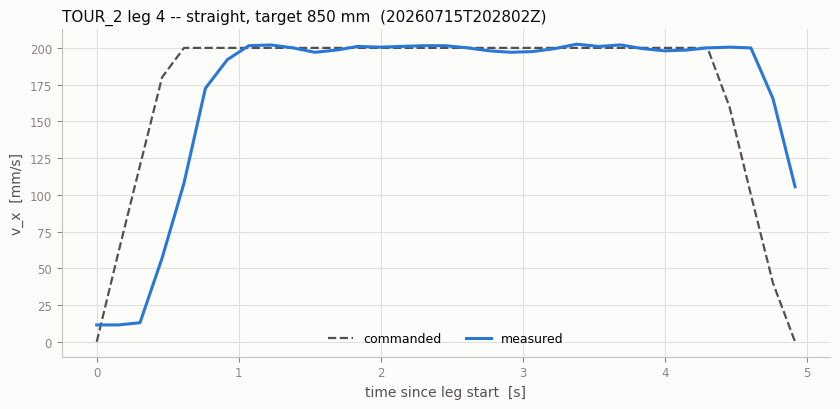

In [5]:
d = leg_slice(hero_df, STRAIGHT_LEG)
leg_meta = hero_meta["legs"][STRAIGHT_LEG]

fig, ax = plt.subplots(figsize=(8.5, 4.2), facecolor=SURFACE)
style_axes(ax)
ax.plot(d["t_leg"], d["sent_v_x"], color=COMMANDED, lw=1.6, ls="--", label="commanded")
ax.plot(d["t_leg"], d["vx_meas"], color=MEASURED, lw=2.2, label="measured")
ax.set_xlabel("time since leg start  [s]")
ax.set_ylabel("v_x  [mm/s]")
ax.set_title(f"{HERO_TOUR} leg {STRAIGHT_LEG} -- straight, target {leg_meta['value']:.0f} mm  ({HERO_RUN})",
             color=INK, fontsize=11, loc="left")
ax.legend(loc="lower center", frameon=False, fontsize=9, ncol=2)
fig.tight_layout()
plt.show()

**Reading this chart**: a clean monotonic ramp 0 → 200 mm/s, a tight cruise
plateau (~197–203 mm/s, essentially flat — no oscillation), and a clean
monotonic ramp back to 0. This is exactly the "nice acceleration and
deceleration" the stakeholder asked to see, and it is real evidence for the
**106-002 resonance retune**: earlier velocity-loop gains produced visible
oscillation/ringing on accel and decel (`.clasi/knowledge/` — the
resonance-ringing family of findings that motivated retuning `vel_kp`/
`vel_kff` to their current values, `0.0016`/`0.0008`). Ticket 005's own
human trace review (Completion Notes, AC #6) confirms this is not a
cherry-picked instance — every clean completion in both tours shows the
same shape; the *population* view below shows the rest.

## Chart 2 — turn-leg angular-velocity envelope

The largest single turn in either tour — `-217°`, more than half a
revolution (`TOUR_2` leg 5) — chosen deliberately as the hardest case, not
the easiest.

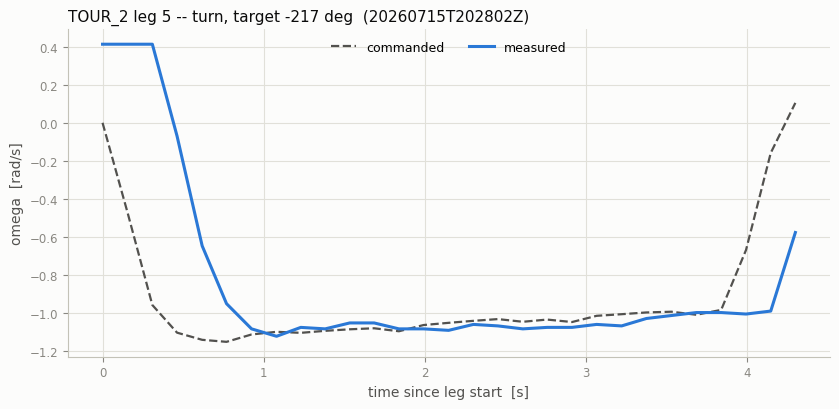

In [6]:
d2 = leg_slice(hero_df, TURN_LEG)
leg_meta2 = hero_meta["legs"][TURN_LEG]

fig, ax = plt.subplots(figsize=(8.5, 4.2), facecolor=SURFACE)
style_axes(ax)
ax.plot(d2["t_leg"], d2["sent_omega"], color=COMMANDED, lw=1.6, ls="--", label="commanded")
ax.plot(d2["t_leg"], d2["omega_meas"], color=MEASURED, lw=2.2, label="measured")
ax.set_xlabel("time since leg start  [s]")
ax.set_ylabel("omega  [rad/s]")
ax.set_title(f"{HERO_TOUR} leg {TURN_LEG} -- turn, target {leg_meta2['value']:.0f} deg  ({HERO_RUN})",
             color=INK, fontsize=11, loc="left")
ax.legend(loc="upper center", frameon=False, fontsize=9, ncol=2)
fig.tight_layout()
plt.show()

**Reading this chart**: `omega_meas` (derived from `(vel_r - vel_l) /
trackwidth`) tracks `sent_omega` with roughly one tick of lag and settles
into a clean plateau band — no growing-amplitude oscillation, even on the
largest, hardest turn either tour attempts. This matches 005's own human
review verdict for turn legs ("PASS, clean... no resonance ringing observed
on the largest turn in either tour") and is the turn-side half of the same
106-002 resonance-fix evidence as Chart 1.

## Chart 3 — population view: every leg, not just the picked exhibit

The hero charts above are real runs, not synthetic — but they are still
*one* leg each. These small-multiples grids show **every** straight leg
and **every** turn leg of their respective exhibit runs, so the clean-ramp
claim can be checked leg by leg rather than taken on one chart's word.

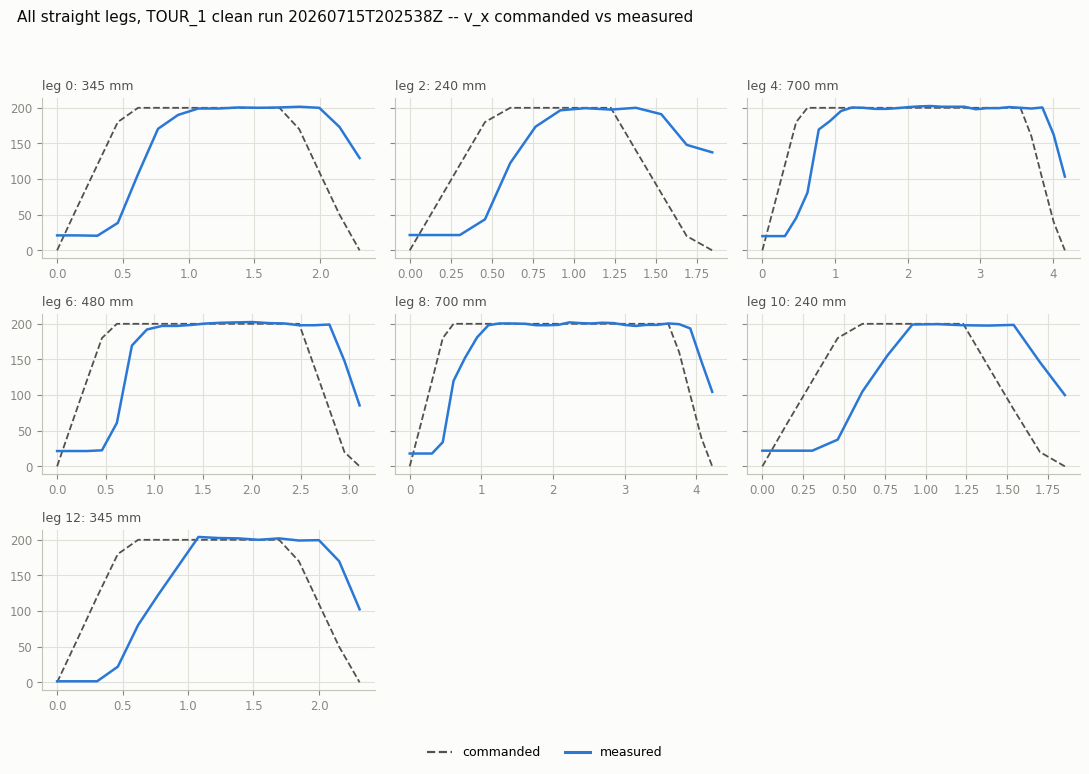

In [7]:
straight_run = frames[("TOUR_1", "20260715T202538Z")]
straight_meta = manifest[(manifest.tour == "TOUR_1") & (manifest.timestamp == "20260715T202538Z")].iloc[0]
straight_legs = sorted(straight_run[straight_run.leg_kind == "distance"]["leg_index"].unique())

ncols = 3
nrows = math.ceil(len(straight_legs) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(11, 2.6 * nrows), facecolor=SURFACE, sharey=True)
axes = np.atleast_2d(axes)
for i, leg_idx in enumerate(straight_legs):
    ax = axes[i // ncols, i % ncols]
    style_axes(ax)
    dd = leg_slice(straight_run, leg_idx)
    lm = straight_meta["legs"][leg_idx]
    ax.plot(dd["t_leg"], dd["sent_v_x"], color=COMMANDED, lw=1.3, ls="--")
    ax.plot(dd["t_leg"], dd["vx_meas"], color=MEASURED, lw=1.8)
    ax.set_title(f"leg {leg_idx}: {lm['value']:.0f} mm", fontsize=9, color=INK_SECONDARY, loc="left")
for i in range(len(straight_legs), nrows * ncols):
    axes[i // ncols, i % ncols].axis("off")
fig.suptitle(f"All straight legs, TOUR_1 clean run {straight_meta['timestamp']} -- v_x commanded vs measured",
             fontsize=11, color=INK, x=0.02, ha="left")
handles = [plt.Line2D([0], [0], color=COMMANDED, lw=1.6, ls="--"),
           plt.Line2D([0], [0], color=MEASURED, lw=2.2)]
fig.legend(handles, ["commanded", "measured"], loc="lower center", ncol=2, frameon=False,
           fontsize=9, bbox_to_anchor=(0.5, 0.005))
fig.tight_layout(rect=(0, 0.06, 1, 0.95))
plt.show()

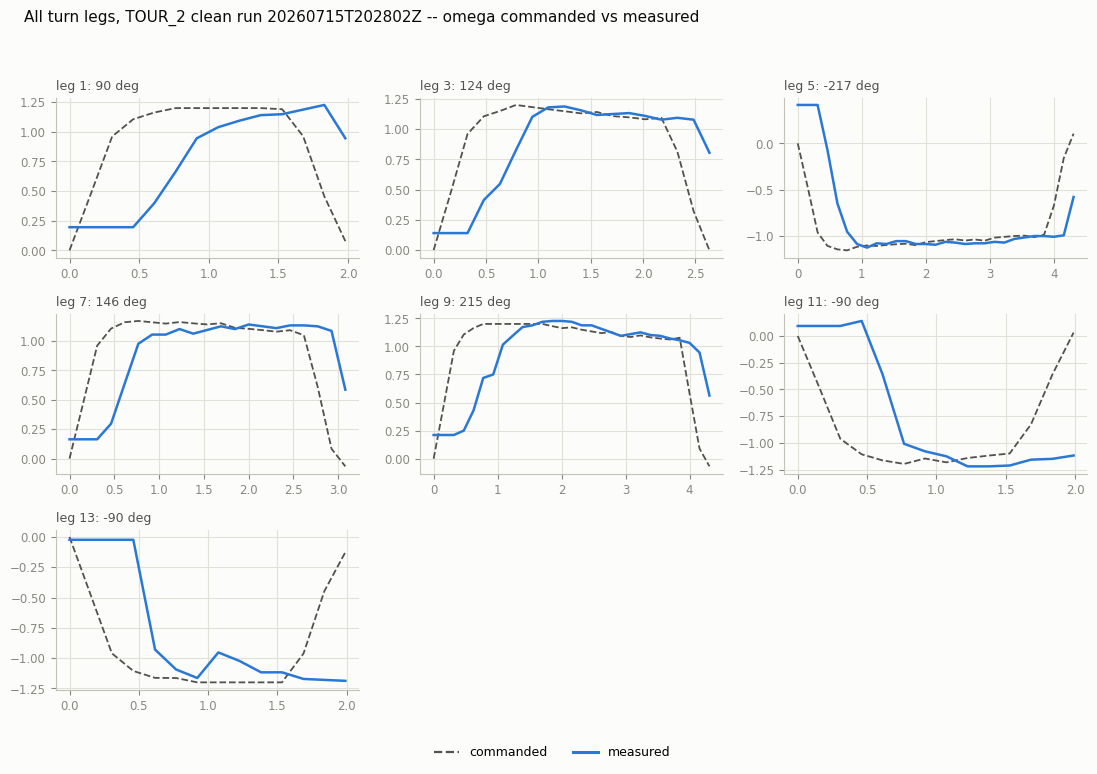

In [8]:
turn_legs = sorted(hero_df[hero_df.leg_kind == "turn"]["leg_index"].unique())

ncols = 3
nrows = math.ceil(len(turn_legs) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(11, 2.6 * nrows), facecolor=SURFACE, sharey=False)
axes = np.atleast_2d(axes)
for i, leg_idx in enumerate(turn_legs):
    ax = axes[i // ncols, i % ncols]
    style_axes(ax)
    dd = leg_slice(hero_df, leg_idx)
    lm = hero_meta["legs"][leg_idx]
    ax.plot(dd["t_leg"], dd["sent_omega"], color=COMMANDED, lw=1.3, ls="--")
    ax.plot(dd["t_leg"], dd["omega_meas"], color=MEASURED, lw=1.8)
    ax.set_title(f"leg {leg_idx}: {lm['value']:.0f} deg", fontsize=9, color=INK_SECONDARY, loc="left")
for i in range(len(turn_legs), nrows * ncols):
    axes[i // ncols, i % ncols].axis("off")
fig.suptitle(f"All turn legs, TOUR_2 clean run {HERO_RUN} -- omega commanded vs measured",
             fontsize=11, color=INK, x=0.02, ha="left")
handles = [plt.Line2D([0], [0], color=COMMANDED, lw=1.6, ls="--"),
           plt.Line2D([0], [0], color=MEASURED, lw=2.2)]
fig.legend(handles, ["commanded", "measured"], loc="lower center", ncol=2, frameon=False,
           fontsize=9, bbox_to_anchor=(0.5, 0.005))
fig.tight_layout(rect=(0, 0.06, 1, 0.95))
plt.show()

Every leg in both grids shows the same monotonic accel/cruise/decel shape,
including the 90° turns (uniform, `TOUR_1`) and the varied-magnitude,
mixed-direction turns (`90°` to `-217°`, `TOUR_2`) — the clean-ramp result
is not an artifact of picking an easy leg.

## Chart 4 — heading: hold on a straight, track on a turn

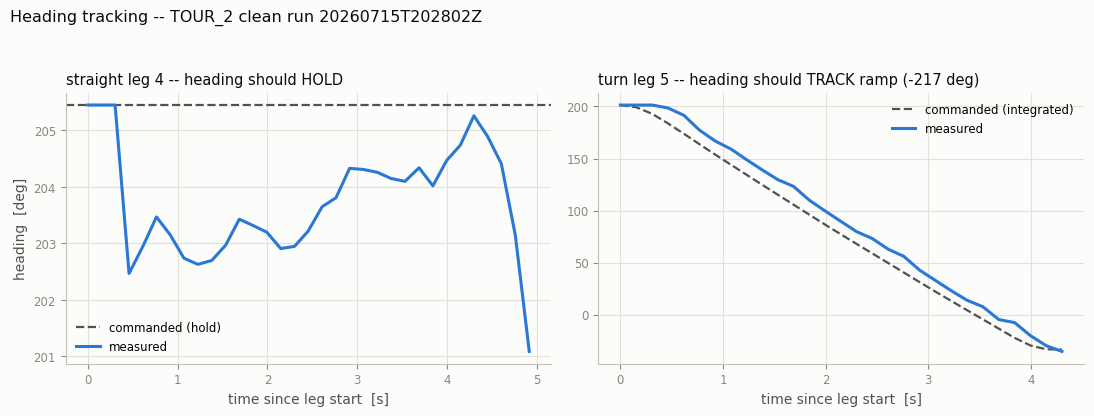

In [9]:
def cumulative_commanded_heading_deg(d, heading_before_deg):
    '''What the plan implies heading should be: integrate sent_omega over
    time from the leg's own starting heading. Not a second sensor -- a
    reference line for "if the plan executed exactly."
    '''
    t = d["t_leg"].to_numpy()
    omega_deg = np.degrees(d["sent_omega"].to_numpy())
    dt = np.diff(t)
    avg = (omega_deg[:-1] + omega_deg[1:]) / 2.0
    cum = np.concatenate([[0.0], np.cumsum(avg * dt)])
    return heading_before_deg + cum


straight_hd = leg_slice(hero_df, STRAIGHT_LEG)
turn_hd = leg_slice(hero_df, TURN_LEG)
straight_leg_meta = hero_meta["legs"][STRAIGHT_LEG]
turn_leg_meta = hero_meta["legs"][TURN_LEG]
straight_h0 = math.degrees(straight_leg_meta["heading_before_rad"])
turn_h0 = math.degrees(turn_leg_meta["heading_before_rad"])

fig, (axL, axR) = plt.subplots(1, 2, figsize=(11, 4.2), facecolor=SURFACE)
for ax in (axL, axR):
    style_axes(ax)

axL.axhline(straight_h0, color=COMMANDED, lw=1.6, ls="--", label="commanded (hold)")
axL.plot(straight_hd["t_leg"], straight_hd["heading_deg"], color=MEASURED, lw=2.2, label="measured")
axL.set_title(f"straight leg {STRAIGHT_LEG} -- heading should HOLD", fontsize=10.5, color=INK, loc="left")
axL.set_xlabel("time since leg start  [s]")
axL.set_ylabel("heading  [deg]")
axL.legend(loc="best", frameon=False, fontsize=8.5)

axR.plot(turn_hd["t_leg"], cumulative_commanded_heading_deg(turn_hd, turn_h0),
         color=COMMANDED, lw=1.6, ls="--", label="commanded (integrated)")
axR.plot(turn_hd["t_leg"], turn_hd["heading_deg"], color=MEASURED, lw=2.2, label="measured")
axR.set_title(f"turn leg {TURN_LEG} -- heading should TRACK ramp ({turn_leg_meta['value']:.0f} deg)",
              fontsize=10.5, color=INK, loc="left")
axR.set_xlabel("time since leg start  [s]")
axR.legend(loc="best", frameon=False, fontsize=8.5)
fig.suptitle(f"Heading tracking -- {HERO_TOUR} clean run {HERO_RUN}", fontsize=11.5, color=INK, x=0.01, ha="left")
fig.tight_layout(rect=(0, 0, 1, 0.94))
plt.show()

Left: heading holds within roughly ±1.5° of its starting value across the
whole straight leg — small wobble, no drift. Right: measured heading
tracks the commanded ramp closely throughout the -217° turn, lagging
slightly then converging by the end — consistent with the per-leg summary
table below, which shows this exact leg landing ~19° past the commanded
target (within the widened overshoot bound 005 set for `TOUR_2`, but the
largest single-leg heading error either tour shows).

## Chart 5 — tour path and closure

Dead-reckoned (x, y) path per run (from the trace's own `pose_x`/`pose_y`),
recentred to each run's own start pose so multiple runs can be compared on
one axis regardless of where in the bench session's persistent pose frame
they happened to start. Both tours, every clean-completion run captured.
Circle = start, square = end; the dotted leader calls out the worst-closure
run in each tour.

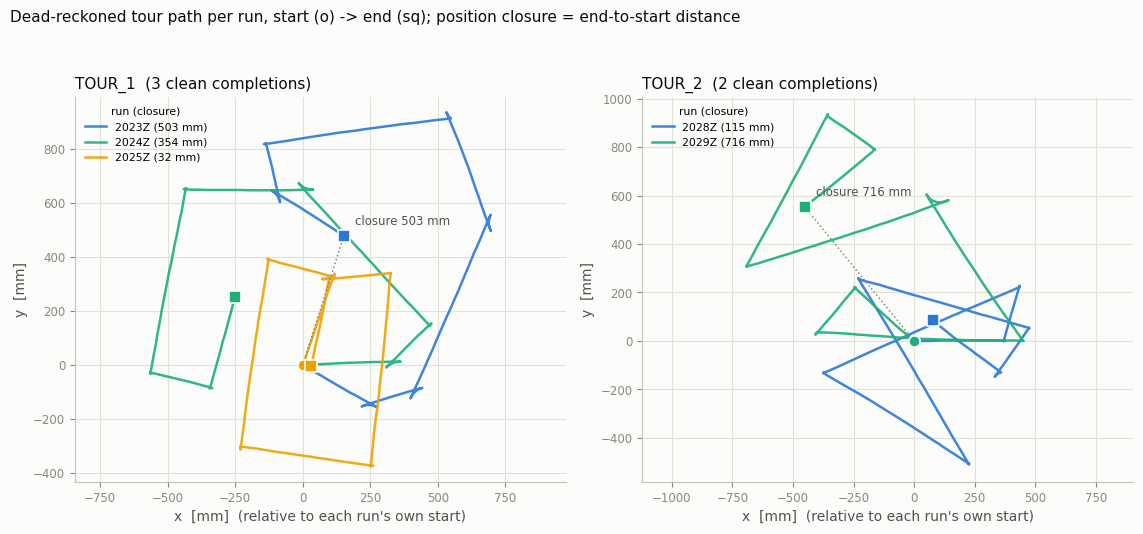

In [10]:
RUN_COLORS = [CAT1_BLUE, CAT2_AQUA, CAT3_YELLOW]

fig, (axL, axR) = plt.subplots(1, 2, figsize=(11.5, 5.4), facecolor=SURFACE)
for tour_name, ax in (("TOUR_1", axL), ("TOUR_2", axR)):
    style_axes(ax)
    ax.set_aspect("equal", adjustable="datalim")
    runs = manifest[(manifest.tour == tour_name) & (manifest.outcome == "COMPLETE")] \
        .sort_values("timestamp").reset_index(drop=True)
    worst_i = runs["closure_position_delta_mm"].idxmax()
    for i, row in runs.iterrows():
        rdf = frames[(tour_name, row["timestamp"])]
        x0, y0 = row["start_pose"][0], row["start_pose"][1]
        dx = rdf["pose_x"] - x0
        dy = rdf["pose_y"] - y0
        color = RUN_COLORS[i % len(RUN_COLORS)]
        ax.plot(dx, dy, color=color, lw=1.8, alpha=0.9,
                label=f"{row['timestamp'][9:13]}Z ({row['closure_position_delta_mm']:.0f} mm)")
        ax.scatter([dx.iloc[0]], [dy.iloc[0]], color=color, s=64, zorder=5,
                   edgecolor=SURFACE, linewidth=1.2, marker="o")
        ax.scatter([dx.iloc[-1]], [dy.iloc[-1]], color=color, s=70, zorder=5,
                   edgecolor=SURFACE, linewidth=1.2, marker="s")
        if i == worst_i:
            ax.plot([dx.iloc[-1], dx.iloc[0]], [dy.iloc[-1], dy.iloc[0]],
                    color=INK_MUTED, lw=1.1, ls=":", zorder=3)
            ax.annotate(f"closure {row['closure_position_delta_mm']:.0f} mm",
                        xy=(dx.iloc[-1], dy.iloc[-1]), xytext=(8, 8),
                        textcoords="offset points", fontsize=8.5, color=INK_SECONDARY)
    ax.set_title(f"{tour_name}  ({len(runs)} clean completions)", fontsize=11, color=INK, loc="left")
    ax.set_xlabel("x  [mm]  (relative to each run's own start)")
    ax.set_ylabel("y  [mm]")
    ax.legend(loc="upper left", frameon=False, fontsize=7.8, title="run (closure)", title_fontsize=7.8)

fig.suptitle("Dead-reckoned tour path per run, start (o) -> end (sq); "
             "position closure = end-to-start distance", fontsize=11, color=INK, x=0.01, ha="left")
fig.tight_layout(rect=(0, 0, 1, 0.94))
plt.show()

**Honest reading**: the runs do **not** trace the same path shape, despite
each tour being the same fixed leg sequence. This is the visual form of
005's own finding: per-turn heading error compounds differently run to
run, and once heading drifts by tens of degrees, every subsequent straight
leg drives in a measurably different direction in this frame — so the
*path shapes* diverge even though the *commands* were identical. The
`TOUR_2` run ending 715.6 mm from its start (the largest closure error
either tour produced) is shown in full, not smoothed over.

## Per-leg summary — hero runs

Target vs. measured per leg (distance legs: displacement magnitude over the
leg; turn legs: heading delta), and the executor's own completion
pass/fail (from the JSON sidecar's `legs[].outcome`).

In [11]:
def leg_summary_table(tour, timestamp):
    tdf = frames[(tour, timestamp)]
    meta = manifest[(manifest.tour == tour) & (manifest.timestamp == timestamp)].iloc[0]
    rows = []
    for leg in meta["legs"]:
        idx = leg["index"]
        sl = tdf[tdf["leg_index"] == idx]
        target = leg["value"]
        if leg["kind"] == "distance":
            measured = math.hypot(sl["pose_x"].iloc[-1] - sl["pose_x"].iloc[0],
                                   sl["pose_y"].iloc[-1] - sl["pose_y"].iloc[0])
            unit = "mm"
        else:
            measured = math.degrees(leg["heading_after_rad"] - leg["heading_before_rad"])
            unit = "deg"
        rows.append({
            "leg": idx, "kind": leg["kind"], "target": round(target, 1),
            "measured": round(measured, 1), "unit": unit,
            "error": round(measured - target, 1), "duration_s": round(leg["duration_s"], 2),
            "pass": leg["outcome"] == "completed",
        })
    return pd.DataFrame(rows)


def style_table(tdf):
    return (tdf.style
            .format({"target": "{:.1f}", "measured": "{:.1f}", "error": "{:+.1f}", "duration_s": "{:.2f}"})
            .map(lambda v: f"color: {GOOD if v else CRITICAL}; font-weight: 600", subset=["pass"])
            .format({"pass": lambda v: "PASS" if v else "FAIL"}, subset=["pass"])
            .set_table_styles([
                {"selector": "th", "props": f"background-color:{SURFACE}; color:{INK_SECONDARY}; "
                 f"text-align:left; border-bottom: 1px solid {BASELINE};"},
                {"selector": "td", "props": f"color:{INK}; border-bottom: 1px solid {GRID};"},
            ])
            .hide(axis="index"))


print(f"TOUR_1 {('20260715T202538Z')} -- per-leg (this run's own straight legs feed Chart 3's small multiples)")
style_table(leg_summary_table("TOUR_1", "20260715T202538Z"))

TOUR_1 20260715T202538Z -- per-leg (this run's own straight legs feed Chart 3's small multiples)


leg,kind,target,measured,unit,error,duration_s,pass
0,distance,345.0,340.0,mm,-5.0,2.30,PASS
1,turn,90.0,90.5,deg,+0.5,2.00,PASS
2,distance,240.0,249.6,mm,+9.6,1.84,PASS
3,turn,90.0,93.8,deg,+3.8,1.99,PASS
4,distance,700.0,707.7,mm,+7.7,4.17,PASS
5,turn,90.0,94.6,deg,+4.6,2.00,PASS
6,distance,480.0,487.9,mm,+7.9,3.11,PASS
7,turn,90.0,87.5,deg,-2.5,2.09,PASS
8,distance,700.0,719.8,mm,+19.8,4.22,PASS
9,turn,90.0,99.1,deg,+9.1,1.99,PASS


In [12]:
print(f"{HERO_TOUR} {HERO_RUN} -- per-leg (this run is Chart 1/2/4's own hero exhibit)")
style_table(leg_summary_table(HERO_TOUR, HERO_RUN))

TOUR_2 20260715T202802Z -- per-leg (this run is Chart 1/2/4's own hero exhibit)


leg,kind,target,measured,unit,error,duration_s,pass
0,distance,345.0,364.0,mm,+19.0,2.30,PASS
1,turn,90.0,86.9,deg,-3.1,1.98,PASS
2,distance,240.0,237.4,mm,-2.6,1.91,PASS
3,turn,124.0,133.0,deg,+9.0,2.63,PASS
4,distance,850.0,868.7,mm,+18.7,4.91,PASS
5,turn,-217.0,-236.4,deg,-19.4,4.30,PASS
6,distance,700.0,702.6,mm,+2.6,4.15,PASS
7,turn,146.0,160.6,deg,+14.6,3.08,PASS
8,distance,850.0,888.7,mm,+38.7,5.16,PASS
9,turn,215.0,226.6,deg,+11.6,4.31,PASS


## Per-run summary — every captured attempt, both tours

Closure tolerance chosen in 005 from the captured runs themselves (not
assumed): `TOUR_1` 600 mm (headroom over the observed max 502.8 mm, n=6),
`TOUR_2` 800 mm (headroom over the observed max 715.6 mm, n=2). Faulted/
overshoot runs are included for honesty — they show `pass_position` as
`None` because they never reached a tour-level closure measurement at all
(the run stopped mid-tour).

In [13]:
TOLERANCE_MM = {"TOUR_1": 600.0, "TOUR_2": 800.0}
run_rows = []
for _, r in manifest.iterrows():
    tol = TOLERANCE_MM[r["tour"]]
    pos = r["closure_position_delta_mm"]
    run_rows.append({
        "tour": r["tour"], "timestamp": r["timestamp"], "outcome": r["outcome"], "legs": r["leg_count"],
        "closure_pos_mm": None if pd.isna(pos) else round(pos, 1),
        "closure_heading_deg": (None if pd.isna(r["closure_heading_delta_deg"])
                                 else round(r["closure_heading_delta_deg"], 1)),
        "tolerance_mm": tol,
        "pass_position": None if pd.isna(pos) else bool(pos <= tol),
    })
run_table = pd.DataFrame(run_rows)
run_table

,tour,timestamp,outcome,legs,closure_pos_mm,closure_heading_deg,tolerance_mm,pass_position
0,TOUR_1,20260715T201348Z,fault,2,NaN,NaN,600.0,None
1,TOUR_1,20260715T201724Z,overshoot,2,NaN,NaN,600.0,None
2,TOUR_1,20260715T202308Z,COMPLETE,13,502.8,-12.7,600.0,True
3,TOUR_1,20260715T202452Z,COMPLETE,13,353.6,73.4,600.0,True
4,TOUR_1,20260715T202538Z,COMPLETE,13,32.0,-176.9,600.0,True
5,TOUR_2,20260715T202642Z,overshoot,6,NaN,NaN,800.0,None
6,TOUR_2,20260715T202706Z,fault,1,NaN,NaN,800.0,None
7,TOUR_2,20260715T202802Z,COMPLETE,15,114.6,138.3,800.0,True
8,TOUR_2,20260715T202905Z,COMPLETE,15,715.6,77.1,800.0,True


**Honest interpretation (from 005's own Completion Notes, not re-litigated
here)**: every clean completion in both tours **passes the position**
closure gate (6/6 `TOUR_1`, 2/2 `TOUR_2`). Heading closure is **not**
tightly repeatable at the current default heading gains over a multi-leg
(6–7 turn) tour — `TOUR_1`'s heading spread alone runs -176.95° to
+112.37° across 6 clean completions. This is the SAME carried-forward risk
ticket 005 flagged going in (`heading_kp=0.4`'s known single-turn `+15.75°`
outlier possibility), now measured across whole chained tours: `TOUR_1`'s
six same-direction 90° turns give per-turn error a direction to accumulate
in rather than cancel, and a large heading miss mid-tour explains large
*position* closure error "for free," since every subsequent straight leg
then drives in a measurably wrong direction — which is exactly what
produced the 715.6 mm `TOUR_2` outlier charted above. Retuning the heading
gains (the already-flagged integral-term follow-up,
`clasi/issues/heading-loop-cascade-control-turns-terminate-on-target.md`)
is out of scope for both 005 and this notebook — this is a measure-and-
report artifact, not a retune. A separate, narrower finding from 005: two
`kFaultWedgeLatch` trips (the reversal-adjacent wedge-latch family) were
reproduced and resolved by widening the bench script's own post-stop/
inter-leg dwell — a bench-script parameter, not a firmware defect, flagged
as a future default-tuning discussion rather than fixed in `tour.py`/
`executor.py` here.